# Stage 4b: The Geometry of Parametric Identifiability

Stage 4b runs **before** inference to detect parameters the data cannot constrain.
It does this by examining the **local geometry** of the moment map — the function
that takes model parameters to observable summary statistics.

The core object is the **sensitivity matrix** $S$, the Jacobian of the moment map
evaluated at prior draws. Its SVD decomposes parameter space into directions
ordered by how much each one changes the observables:

$$S = U \Sigma V^\top$$

- Each column of $V$ (right singular vector $\mathbf{v}_k$) is a **direction in parameter space**.
- Its singular value $\sigma_k$ measures how much the observables change when you move one unit in that direction.
- A tiny $\sigma_k$ means a **nearly-flat direction** — a ridge or valley where the likelihood provides almost no information.

The **dominant loadings** of a weak right-singular vector tell you which named parameters
make up that flat direction. For example:

```
+0.71  beta_A_to_B
-0.69  beta_B_to_A
```

means: increase `beta_A_to_B` while decreasing `beta_B_to_A` and the model output barely moves.

This notebook builds three toy examples from scratch to develop geometric intuition.

In [4]:
%pip install numpy scipy matplotlib

  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 83.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 81.2 MB/s eta 0:00:00
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 83.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import matplotlib.gridspec as gridspec

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [6]:
def numerical_jacobian(moment_fn, theta_0, eps=1e-5):
    """Compute the Jacobian of moment_fn at theta_0 via central differences.
    
    Returns S with shape (n_moments, n_parameters).
    """
    m0 = moment_fn(theta_0)
    n_obs = m0.shape[0]
    n_params = theta_0.shape[0]
    S = np.zeros((n_obs, n_params))
    for j in range(n_params):
        e_j = np.zeros(n_params)
        e_j[j] = eps
        S[:, j] = (moment_fn(theta_0 + e_j) - moment_fn(theta_0 - e_j)) / (2 * eps)
    return S


def svd_report(S, param_names, *, normalized=False):
    """Run the SVD and print a report. Only apply severity bands if normalized=True."""
    U, sigma, Vt = np.linalg.svd(S, full_matrices=False)
    V = Vt.T  # columns are right-singular vectors
    
    print("Singular values:")
    for k, sv in enumerate(sigma):
        if normalized:
            status = "pass" if sv > 10 else ("warn" if sv > 1 else "FAIL")
            print(f"  sigma_{k+1} = {sv:10.4f}  [{status}]")
        else:
            print(f"  sigma_{k+1} = {sv:10.4f}")
    
    print("\nRight-singular vectors (columns = directions in parameter space):")
    for k in range(len(sigma)):
        print(f"\n  Direction {k+1} (sigma={sigma[k]:.4f}):")
        order = np.argsort(np.abs(V[:, k]))[::-1]
        for idx in order:
            print(f"    {V[idx, k]:+.4f}  {param_names[idx]}")
    
    return sigma, V


def loss_landscape(moment_fn, theta_0, param_names, idx_x, idx_y, 
                   delta_x=0.5, delta_y=0.5, n_grid=80, ax=None):
    """Plot the squared-error loss surface over two parameters, with others fixed."""
    m_true = moment_fn(theta_0)
    
    xs = np.linspace(theta_0[idx_x] - delta_x, theta_0[idx_x] + delta_x, n_grid)
    ys = np.linspace(theta_0[idx_y] - delta_y, theta_0[idx_y] + delta_y, n_grid)
    X, Y = np.meshgrid(xs, ys)
    Z = np.zeros_like(X)
    
    for i in range(n_grid):
        for j in range(n_grid):
            theta = theta_0.copy()
            theta[idx_x] = X[i, j]
            theta[idx_y] = Y[i, j]
            residual = moment_fn(theta) - m_true
            Z[i, j] = np.sum(residual**2)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    
    levels = np.linspace(0, np.percentile(Z, 60), 20)
    ax.contourf(X, Y, Z, levels=levels, cmap="RdYlGn_r", alpha=0.8)
    ax.contour(X, Y, Z, levels=levels, colors="k", linewidths=0.3)
    ax.plot(theta_0[idx_x], theta_0[idx_y], "k*", ms=12, zorder=5)
    ax.set_xlabel(param_names[idx_x])
    ax.set_ylabel(param_names[idx_y])
    return ax

## Example 1: Well-Identified Exponential Decay

A single exponential decay observed at 10 time points:

$$y(t) = a \cdot e^{-b \cdot t}$$

Parameters $\theta = (a, b)$. The amplitude $a$ scales the curve vertically; the rate $b$
controls how fast it decays. These affect the trajectory in linearly independent ways,
so both singular values should be healthy.

In [7]:
times = np.linspace(0.1, 3.0, 10)

def moment_map_decay(theta):
    """Moment map: parameters -> observable mean trajectory."""
    a, b = theta
    return a * np.exp(-b * times)

theta_0 = np.array([2.0, 1.0])
param_names = ["amplitude (a)", "rate (b)"]

S = numerical_jacobian(moment_map_decay, theta_0)
print(f"Sensitivity matrix S: {S.shape[0]} observations x {S.shape[1]} parameters\n")
sigma, V = svd_report(S, param_names)

print(f"\nCondition ratio: sigma_1 / sigma_2 = {sigma[0]/sigma[1]:.1f}x")
print("Both directions have comparable sensitivity -> well-identified.")

Sensitivity matrix S: 10 observations x 2 parameters

Singular values:
  sigma_1 =     2.0008
  sigma_2 =     0.8158

Right-singular vectors (columns = directions in parameter space):

  Direction 1 (sigma=2.0008):
    +0.8270  rate (b)
    -0.5623  amplitude (a)

  Direction 2 (sigma=0.8158):
    +0.8270  amplitude (a)
    +0.5623  rate (b)

Condition ratio: sigma_1 / sigma_2 = 2.5x
Both directions have comparable sensitivity -> well-identified.


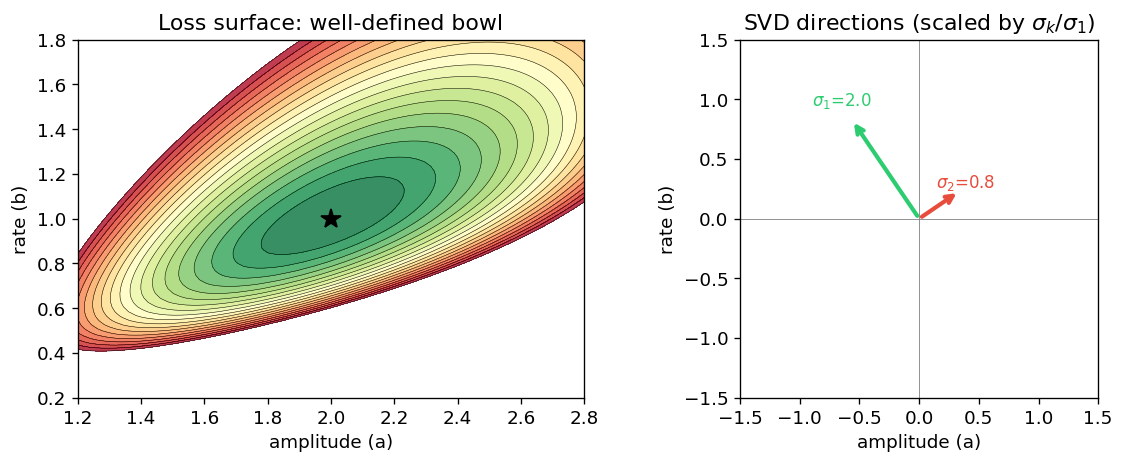

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Loss landscape
loss_landscape(moment_map_decay, theta_0, param_names, 0, 1, 
               delta_x=0.8, delta_y=0.8, ax=axes[0])
axes[0].set_title("Loss surface: well-defined bowl")

# SVD direction arrows
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_aspect("equal")
axes[1].axhline(0, color="grey", lw=0.5)
axes[1].axvline(0, color="grey", lw=0.5)

colors = ["#2ecc71", "#e74c3c"]
for k in range(2):
    scale = sigma[k] / sigma[0]  # normalize to strongest
    dx, dy = V[0, k] * scale, V[1, k] * scale
    axes[1].annotate("", xy=(dx, dy), xytext=(0, 0),
                     arrowprops=dict(arrowstyle="->", color=colors[k], lw=2.5))
    axes[1].text(dx * 1.15, dy * 1.15, 
                 f"$\\sigma_{k+1}$={sigma[k]:.1f}", fontsize=10, color=colors[k],
                 ha="center")

axes[1].set_xlabel(param_names[0])
axes[1].set_ylabel(param_names[1])
axes[1].set_title("SVD directions (scaled by $\\sigma_k / \\sigma_1$)")
plt.tight_layout()
plt.show()

## Example 2: Structural Non-Identifiability (Only the Sum Matters)

Now consider a model where two rate parameters enter only through their sum:

$$y(t) = e^{-(\alpha + \beta) \cdot t}$$

Individually, $\alpha$ and $\beta$ are meaningless — only $\alpha + \beta$ is determined by the data.
The SVD should reveal a **zero singular value** whose right-singular vector points along
the direction $(\alpha, -\beta)$ — increase one, decrease the other by the same amount, nothing changes.

In [9]:
def moment_map_sum(theta):
    """Only the sum alpha + beta matters."""
    alpha, beta = theta
    return np.exp(-(alpha + beta) * times)

theta_0 = np.array([0.5, 0.5])
param_names_sum = ["alpha", "beta"]

S = numerical_jacobian(moment_map_sum, theta_0)
sigma, V = svd_report(S, param_names_sum)

Singular values:
  sigma_1 =     1.2141
  sigma_2 =     0.0000

Right-singular vectors (columns = directions in parameter space):

  Direction 1 (sigma=1.2141):
    +0.7071  alpha
    +0.7071  beta

  Direction 2 (sigma=0.0000):
    +0.7071  beta
    -0.7071  alpha


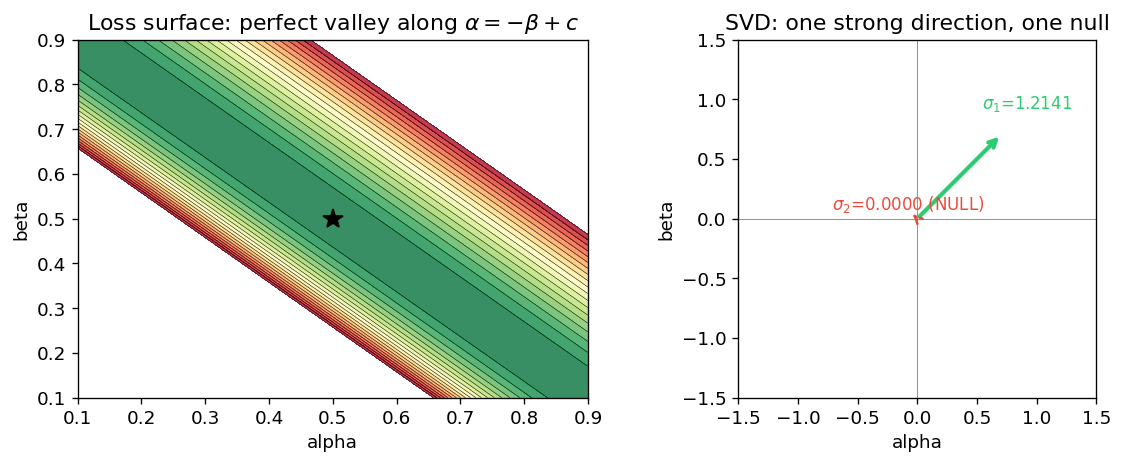

The null direction has loadings (+0.71, -0.71):
  -> increase alpha, decrease beta by the same amount -> no change in y(t).
  -> Stage 4b would flag this as STRUCTURAL non-identifiability.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

loss_landscape(moment_map_sum, theta_0, param_names_sum, 0, 1, 
               delta_x=0.4, delta_y=0.4, ax=axes[0])
axes[0].set_title("Loss surface: perfect valley along $\\alpha = -\\beta + c$")

# SVD directions
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_aspect("equal")
axes[1].axhline(0, color="grey", lw=0.5)
axes[1].axvline(0, color="grey", lw=0.5)

for k in range(2):
    scale = max(sigma[k] / sigma[0], 0.08)  # show zero direction as short dashed
    dx, dy = V[0, k] * scale, V[1, k] * scale
    style = "->" if sigma[k] > 0.01 else "->"
    lw = 2.5 if sigma[k] > 0.01 else 1.5
    ls = "-" if sigma[k] > 0.01 else "--"
    axes[1].annotate("", xy=(dx, dy), xytext=(0, 0),
                     arrowprops=dict(arrowstyle=style, color=colors[k], lw=lw, ls=ls))
    label = f"$\\sigma_{k+1}$={sigma[k]:.4f}"
    if sigma[k] < 0.01:
        label += " (NULL)"
    axes[1].text(dx * 1.3, dy * 1.3, label, fontsize=10, color=colors[k], ha="center")

axes[1].set_xlabel(param_names_sum[0])
axes[1].set_ylabel(param_names_sum[1])
axes[1].set_title("SVD: one strong direction, one null")
plt.tight_layout()
plt.show()

print("The null direction has loadings (+0.71, -0.71):")
print("  -> increase alpha, decrease beta by the same amount -> no change in y(t).")
print("  -> Stage 4b would flag this as STRUCTURAL non-identifiability.")

## Example 3: CT-SEM Ridge — Reciprocal Cross-Effects

This is the realistic case Stage 4b is designed to catch.

Consider a continuous-time latent state-space model with two latents $A$ and $B$
that mutually influence each other:

$$\frac{d}{dt}\begin{pmatrix} A \\ B \end{pmatrix} = \underbrace{\begin{pmatrix} -\rho_A & \beta_{A \leftarrow B} \\ \beta_{B \leftarrow A} & -\rho_B \end{pmatrix}}_{=\, \text{drift } \mathbf{F}} \begin{pmatrix} A \\ B \end{pmatrix}$$

Both latents are directly observed (identity measurement model $\Lambda = I$).

The **observable moments** (mean trajectories at discrete time points) depend on the
matrix exponential $e^{\mathbf{F} \cdot \Delta t}$, whose eigenvalues are:

$$\lambda_{1,2} = \frac{-(\rho_A + \rho_B) \pm \sqrt{(\rho_A - \rho_B)^2 + 4 \cdot \beta_{A \leftarrow B} \cdot \beta_{B \leftarrow A}}}{2}$$

When $\rho_A = \rho_B$, the eigenvalues depend on the **product**
$\beta_{A \leftarrow B} \cdot \beta_{B \leftarrow A}$. With a symmetric initial condition
$x_0 = (1, 1)$, the mean trajectory projects almost entirely onto one eigenvector,
making it insensitive to which cross-effect is which. This creates a **ridge**: you can
trade off one cross-effect against the other, and the observables barely change.

The SVD detects this as a weak direction with loadings $(+0.71, -0.71)$.

In [11]:
# CT-SEM moment map: parameters -> mean trajectory at observation times
#
# We fix rho_A = rho_B = 1.0 and use a symmetric initial condition x0 = [1, 1].
# The two cross-effects beta_AB and beta_BA enter symmetrically, which is when
# the ridge is most severe.

obs_times = np.linspace(0.2, 4.0, 15)

def ct_sem_moment_map(theta):
    """Mean trajectory of 2-latent CT-SEM, observed at discrete times.
    
    Parameters: theta = [beta_A<-B, beta_B<-A]
    Fixed: rho_A = rho_B = 1.0, x0 = [1, 1]
    Returns: flattened [A(t1), B(t1), A(t2), B(t2), ...] — shape (2*T,)
    """
    beta_AB, beta_BA = theta
    F = np.array([[-1.0, beta_AB],
                  [beta_BA, -1.0]])
    x0 = np.array([1.0, 1.0])
    
    trajectory = []
    for t in obs_times:
        x_t = expm(F * t) @ x0
        trajectory.append(x_t)
    return np.concatenate(trajectory)

# True parameter: moderate cross-effects (large enough to create a visible ridge)
theta_true = np.array([0.7, 0.7])
param_names_ct = ["beta_A<-B", "beta_B<-A"]

S = numerical_jacobian(ct_sem_moment_map, theta_true)
print(f"Sensitivity matrix: {S.shape[0]} moment features x {S.shape[1]} parameters\n")
sigma, V = svd_report(S, param_names_ct)

ratio = sigma[0] / sigma[1]
print(f"\nCondition ratio: sigma_1 / sigma_2 = {ratio:.1f}x")
print("The strong direction (+0.71, +0.71) = 'change both together' is well-sensed.")
print("The weak direction (+0.71, -0.71) = 'trade one for the other' is a ridge.")

Sensitivity matrix: 30 moment features x 2 parameters

Singular values:
  sigma_1 =     3.9246
  sigma_2 =     1.2433

Right-singular vectors (columns = directions in parameter space):

  Direction 1 (sigma=3.9246):
    -0.7071  beta_A<-B
    -0.7071  beta_B<-A

  Direction 2 (sigma=1.2433):
    -0.7071  beta_B<-A
    +0.7071  beta_A<-B

Condition ratio: sigma_1 / sigma_2 = 3.2x
The strong direction (+0.71, +0.71) = 'change both together' is well-sensed.
The weak direction (+0.71, -0.71) = 'trade one for the other' is a ridge.


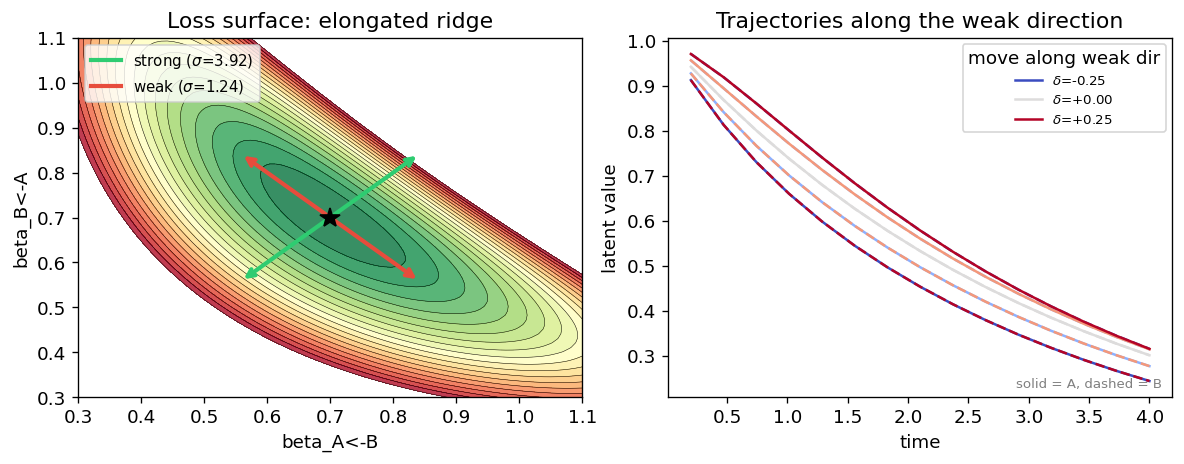


Condition ratio: sigma_1 / sigma_2 = 3.2x
The weak direction has loadings:
  -0.7071  beta_B<-A
  +0.7071  beta_A<-B

-> Increasing beta_A<-B while decreasing beta_B<-A barely changes the trajectories.
   This is a RIDGE in likelihood space that would slow down or confuse inference.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

loss_landscape(ct_sem_moment_map, theta_true, param_names_ct, 0, 1,
               delta_x=0.4, delta_y=0.4, ax=axes[0])
axes[0].set_title("Loss surface: elongated ridge")

# Show the ridge direction from SVD
weak_idx = np.argmin(sigma)
strong_idx = np.argmax(sigma)
v_weak = V[:, weak_idx]
v_strong = V[:, strong_idx]

# Draw the directions on the loss surface
for v, color in [(v_strong, "#2ecc71"), (v_weak, "#e74c3c")]:
    scale = 0.2
    axes[0].annotate("", 
                     xy=(theta_true[0] + v[0]*scale, theta_true[1] + v[1]*scale),
                     xytext=(theta_true[0], theta_true[1]),
                     arrowprops=dict(arrowstyle="->", color=color, lw=2.5))
    axes[0].annotate("", 
                     xy=(theta_true[0] - v[0]*scale, theta_true[1] - v[1]*scale),
                     xytext=(theta_true[0], theta_true[1]),
                     arrowprops=dict(arrowstyle="->", color=color, lw=2.5))

axes[0].legend(
    handles=[plt.Line2D([0], [0], color="#2ecc71", lw=2.5, label=f"strong ($\\sigma$={sigma[strong_idx]:.2f})"),
             plt.Line2D([0], [0], color="#e74c3c", lw=2.5, label=f"weak ($\\sigma$={sigma[weak_idx]:.2f})")],
    loc="upper left", fontsize=9)

# Right panel: what the trajectories look like along the ridge
axes[1].set_title("Trajectories along the weak direction")
offsets = np.linspace(-0.25, 0.25, 5)
cmap = plt.cm.coolwarm
for i, delta in enumerate(offsets):
    theta_shifted = theta_true + delta * v_weak
    traj = ct_sem_moment_map(theta_shifted).reshape(-1, 2)
    color = cmap(i / (len(offsets) - 1))
    axes[1].plot(obs_times, traj[:, 0], color=color, lw=1.5,
                 label=f"$\\delta$={delta:+.2f}" if i in [0, 2, 4] else None)
    axes[1].plot(obs_times, traj[:, 1], color=color, lw=1.5, ls="--")

axes[1].set_xlabel("time")
axes[1].set_ylabel("latent value")
axes[1].legend(fontsize=8, title="move along weak dir")
axes[1].text(0.98, 0.02, "solid = A, dashed = B", transform=axes[1].transAxes,
             ha="right", va="bottom", fontsize=8, color="grey")
plt.tight_layout()
plt.show()

print(f"\nCondition ratio: sigma_1 / sigma_2 = {ratio:.1f}x")
print("The weak direction has loadings:")
for idx in np.argsort(np.abs(V[:, weak_idx]))[::-1]:
    print(f"  {V[idx, weak_idx]:+.4f}  {param_names_ct[idx]}")
print("\n-> Increasing beta_A<-B while decreasing beta_B<-A barely changes the trajectories.")
print("   This is a RIDGE in likelihood space that would slow down or confuse inference.")

### Breaking the symmetry

The ridge exists because the system is symmetric: $\rho_A = \rho_B$, $\beta_{A \leftarrow B} = \beta_{B \leftarrow A}$,
and $x_0 = (1, 1)$. Real systems rarely have all three symmetries. Breaking any one of them
introduces information that distinguishes the two cross-effects:

1. **Asymmetric initial conditions** $x_0 = (1, 0)$ — only $A$ starts active, so $\beta_{B \leftarrow A}$
   acts immediately while $\beta_{A \leftarrow B}$ has to wait for $B$ to grow.
2. **Asymmetric auto-regression rates** $\rho_A \neq \rho_B$ — different decay rates break the eigenvector symmetry.
3. **Non-identity measurement** $\Lambda \neq I$ — observing latents through different loadings.

In [13]:
def ct_sem_moment_map_asymmetric(theta):
    """Same CT-SEM but with asymmetric initial conditions and rates."""
    beta_AB, beta_BA = theta
    F = np.array([[-0.8, beta_AB],     # rho_A = 0.8
                  [beta_BA, -1.5]])     # rho_B = 1.5 (faster decay)
    x0 = np.array([1.0, 0.0])          # only A starts active
    trajectory = []
    for t in obs_times:
        x_t = expm(F * t) @ x0
        trajectory.append(x_t)
    return np.concatenate(trajectory)

theta_asym = np.array([0.7, 0.7])

S_asym = numerical_jacobian(ct_sem_moment_map_asymmetric, theta_asym)
sigma_asym, V_asym = svd_report(S_asym, param_names_ct)

weak_asym = np.argmin(sigma_asym)
print(f"\nCondition ratio: {sigma_asym[0]/sigma_asym[1]:.1f}x")
print(f"\nCompare to symmetric: loadings were exactly (+0.71, -0.71).")
print(f"Here the weak direction loadings are ({V_asym[0,weak_asym]:+.2f}, {V_asym[1,weak_asym]:+.2f}).")
print("The asymmetry rotates the weak direction — now one cross-effect contributes")
print("more to the ridge than the other, giving Stage 4b a more specific diagnosis.")

Singular values:
  sigma_1 =     1.7346
  sigma_2 =     0.5239

Right-singular vectors (columns = directions in parameter space):

  Direction 1 (sigma=1.7346):
    -0.8852  beta_B<-A
    -0.4652  beta_A<-B

  Direction 2 (sigma=0.5239):
    +0.8852  beta_A<-B
    -0.4652  beta_B<-A

Condition ratio: 3.3x

Compare to symmetric: loadings were exactly (+0.71, -0.71).
Here the weak direction loadings are (+0.89, -0.47).
The asymmetry rotates the weak direction — now one cross-effect contributes
more to the ridge than the other, giving Stage 4b a more specific diagnosis.


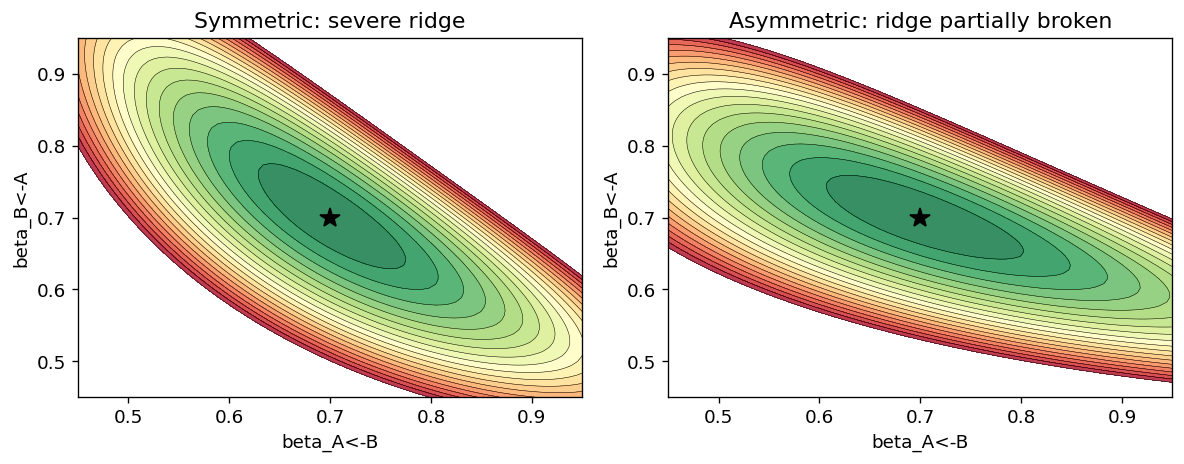

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

loss_landscape(ct_sem_moment_map, theta_true, param_names_ct, 0, 1,
               delta_x=0.25, delta_y=0.25, ax=axes[0])
axes[0].set_title("Symmetric: severe ridge")

loss_landscape(ct_sem_moment_map_asymmetric, theta_asym, param_names_ct, 0, 1,
               delta_x=0.25, delta_y=0.25, ax=axes[1])
axes[1].set_title("Asymmetric: ridge partially broken")

plt.tight_layout()
plt.show()

## Stage 4b Normalization

Raw singular values depend on the units of both the parameters and the observations.
A raw $\sigma = 0.01$ could be fine (if the parameter has a tiny prior SD) or terrible
(if the parameter ranges over decades). Stage 4b normalizes:

$$S_{\text{norm}} = \text{diag}\!\left(\frac{1}{\text{obs\_noise}}\right) \cdot S \cdot \text{diag}(\text{prior\_std})$$

This makes each column of $S_{\text{norm}}$ represent a **one-prior-SD move** in that
parameter, and each row measures the change **relative to observation noise**. A
normalized singular value of 1 means "a one-sigma prior move creates a one-noise-SD
change in predictions" — the boundary where data starts to be informative.

**Severity bands** (from `sensitivity.py`):
| Normalized $\sigma$ | Status | Meaning |
|---|---|---|
| $> 10$ | **pass** | Well-identified: data strongly constrains this direction |
| $1 < \sigma \leq 10$ | **warn** | Weakly identified: data provides some info but prior matters a lot |
| $\leq 1$ | **fail** | Not identified: this direction is flat relative to noise |

In [15]:
# Demonstrate the effect of normalization on the CT-SEM example.
#
# Scenario: beta_A<-B has a wide prior (SD=1.0), beta_B<-A has a tight prior (SD=0.1).
# Observation noise SD = 0.3 for both channels.

prior_std = np.array([1.0, 0.1])   # wide prior on beta_AB, tight on beta_BA
obs_noise = 0.3

S_raw = numerical_jacobian(ct_sem_moment_map, theta_true)

# Normalize: scale columns by prior_std, rows by 1/obs_noise
S_norm = (prior_std[None, :] / obs_noise) * S_raw

print("=== Raw SVD ===")
sigma_raw, V_raw = svd_report(S_raw, param_names_ct)

print("\n=== Normalized SVD (prior_std=[1.0, 0.1], obs_noise=0.3) ===")
sigma_norm, V_norm = svd_report(S_norm, param_names_ct, normalized=True)

=== Raw SVD ===
Singular values:
  sigma_1 =     3.9246
  sigma_2 =     1.2433

Right-singular vectors (columns = directions in parameter space):

  Direction 1 (sigma=3.9246):
    -0.7071  beta_A<-B
    -0.7071  beta_B<-A

  Direction 2 (sigma=1.2433):
    -0.7071  beta_B<-A
    +0.7071  beta_A<-B

=== Normalized SVD (prior_std=[1.0, 0.1], obs_noise=0.3) ===
Singular values:
  sigma_1 =     9.7359  [warn]
  sigma_2 =     0.5569  [FAIL]

Right-singular vectors (columns = directions in parameter space):

  Direction 1 (sigma=9.7359):
    -0.9967  beta_A<-B
    -0.0818  beta_B<-A

  Direction 2 (sigma=0.5569):
    -0.9967  beta_B<-A
    +0.0818  beta_A<-B


In [16]:
print("Key insight: normalization changes which directions matter.\n")
print("With equal priors, the raw SVD found a symmetric ridge (+0.7, -0.7).")
print("With asymmetric priors (beta_A<-B much wider), the normalized SVD")
print("tells you that the wide-prior parameter dominates the weak direction —")
print("because a 1-sigma move in beta_A<-B is 10x larger than one in beta_B<-A.")
print()
print("The normalized singular value tells Stage 4b whether the DATA can")
print("overcome the PRIOR uncertainty in that direction.")

Key insight: normalization changes which directions matter.

With equal priors, the raw SVD found a symmetric ridge (+0.7, -0.7).
With asymmetric priors (beta_A<-B much wider), the normalized SVD
tells you that the wide-prior parameter dominates the weak direction —
because a 1-sigma move in beta_A<-B is 10x larger than one in beta_B<-A.

The normalized singular value tells Stage 4b whether the DATA can
overcome the PRIOR uncertainty in that direction.


## Full CT-SEM Example: All Parameters

In a real model, Stage 4b analyzes all parameters simultaneously — not just cross-effects.
Let's expand the CT-SEM to include auto-regression rates $(\rho_A, \rho_B)$, cross-effects
$(\beta_{A \leftarrow B}, \beta_{B \leftarrow A})$, and process noise scales $(\sigma_A, \sigma_B)$.

The moment map now includes both the **mean trajectory** and the **same-time covariance**
(since process noise affects the spread but not the mean, it can only be identified through
second-order statistics).

In [17]:
def ct_sem_full_moments(theta):
    """Moment map for full CT-SEM: mean trajectory + stationary covariance elements.
    
    theta = [rho_A, rho_B, beta_AB, beta_BA, sigma_A, sigma_B]
    
    The mean trajectory is computed via matrix exponential.
    The stationary covariance P_inf solves the Lyapunov equation: F @ P + P @ F.T + Q = 0
    We include the unique elements of P_inf as additional moment features,
    since process noise only affects second-order statistics.
    """
    from scipy.linalg import solve_continuous_lyapunov
    
    rho_A, rho_B, beta_AB, beta_BA, sigma_A, sigma_B = theta
    F = np.array([[-rho_A, beta_AB],
                  [beta_BA, -rho_B]])
    Q = np.diag([sigma_A**2, sigma_B**2])  # diffusion covariance
    x0 = np.array([1.0, 0.0])
    
    # Mean trajectory
    means = []
    for t in obs_times:
        x_t = expm(F * t) @ x0
        means.append(x_t)
    mean_flat = np.concatenate(means)
    
    # Stationary covariance: solve F @ P + P @ F.T + Q = 0
    P_inf = solve_continuous_lyapunov(F, -Q)
    
    # Extract unique elements: P_AA, P_AB, P_BB
    cov_features = np.array([P_inf[0, 0], P_inf[0, 1], P_inf[1, 1]])
    
    return np.concatenate([mean_flat, cov_features])

theta_full = np.array([1.0, 1.0, 0.3, 0.3, 0.5, 0.5])
param_names_full = ["rho_A", "rho_B", "beta_A<-B", "beta_B<-A", "sigma_A", "sigma_B"]

S_full = numerical_jacobian(ct_sem_full_moments, theta_full)
print(f"Sensitivity matrix: {S_full.shape[0]} moments x {S_full.shape[1]} parameters\n")
sigma_full, V_full = svd_report(S_full, param_names_full)

Sensitivity matrix: 33 moments x 6 parameters

Singular values:
  sigma_1 =     1.3306
  sigma_2 =     0.8462
  sigma_3 =     0.5691
  sigma_4 =     0.5000
  sigma_5 =     0.1352
  sigma_6 =     0.1020

Right-singular vectors (columns = directions in parameter space):

  Direction 1 (sigma=1.3306):
    +0.6902  rho_A
    -0.6802  beta_B<-A
    -0.1683  beta_A<-B
    +0.1677  rho_B
    -0.0556  sigma_A
    -0.0390  sigma_B

  Direction 2 (sigma=0.8462):
    +0.6893  beta_B<-A
    +0.6786  rho_A
    -0.1669  rho_B
    -0.1504  beta_A<-B
    -0.1008  sigma_A
    +0.0610  sigma_B

  Direction 3 (sigma=0.5691):
    -0.7808  sigma_B
    -0.5780  sigma_A
    +0.1948  rho_B
    +0.0859  beta_B<-A
    -0.0756  beta_A<-B
    -0.0718  rho_A

  Direction 4 (sigma=0.5000):
    +0.8042  sigma_A
    -0.5620  sigma_B
    +0.1299  rho_B
    +0.1021  rho_A
    +0.1000  beta_B<-A
    +0.0080  beta_A<-B

  Direction 5 (sigma=0.1352):
    -0.8514  beta_A<-B
    +0.4386  rho_B
    -0.1941  rho_A
    +0.1708

In [18]:
# Stage 4b-style report: highlight weak directions and their dominant parameters

print("=" * 60)
print("Stage 4b Report: Weak Directions")
print("=" * 60)

for k in range(len(sigma_full)):
    sv = sigma_full[k]
    status = "pass" if sv > 10 else ("warn" if sv > 1 else "FAIL")
    if status == "pass":
        continue
    
    print(f"\nDirection {k+1}: sigma = {sv:.4f} [{status}]")
    print("  Dominant parameters (top loadings):")
    loadings = V_full[:, k].copy()
    # Flip sign so largest loading is positive (convention from sensitivity.py)
    if loadings[np.argmax(np.abs(loadings))] < 0:
        loadings *= -1
    order = np.argsort(np.abs(loadings))[::-1]
    for idx in order[:4]:
        print(f"    {loadings[idx]:+.4f}  {param_names_full[idx]}")
    
    top2 = order[:2]
    signs = ["increase" if loadings[i] > 0 else "decrease" for i in top2]
    print(f"  -> {signs[0]} {param_names_full[top2[0]]}, {signs[1]} {param_names_full[top2[1]]}")
    print(f"     observables barely change (sigma = {sv:.4f})")

if all(sv > 10 for sv in sigma_full):
    print("\nAll directions pass -> model is well-identified at this parameter point.")

Stage 4b Report: Weak Directions

Direction 1: sigma = 1.3306 [warn]
  Dominant parameters (top loadings):
    +0.6902  rho_A
    -0.6802  beta_B<-A
    -0.1683  beta_A<-B
    +0.1677  rho_B
  -> increase rho_A, decrease beta_B<-A
     observables barely change (sigma = 1.3306)

Direction 2: sigma = 0.8462 [FAIL]
  Dominant parameters (top loadings):
    +0.6893  beta_B<-A
    +0.6786  rho_A
    -0.1669  rho_B
    -0.1504  beta_A<-B
  -> increase beta_B<-A, increase rho_A
     observables barely change (sigma = 0.8462)

Direction 3: sigma = 0.5691 [FAIL]
  Dominant parameters (top loadings):
    +0.7808  sigma_B
    +0.5780  sigma_A
    -0.1948  rho_B
    -0.0859  beta_B<-A
  -> increase sigma_B, increase sigma_A
     observables barely change (sigma = 0.5691)

Direction 4: sigma = 0.5000 [FAIL]
  Dominant parameters (top loadings):
    +0.8042  sigma_A
    -0.5620  sigma_B
    +0.1299  rho_B
    +0.1021  rho_A
  -> increase sigma_A, decrease sigma_B
     observables barely change (sig

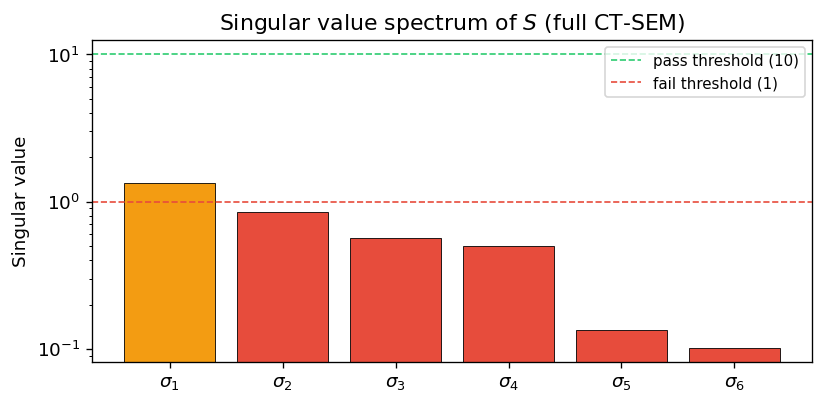

In [19]:
# Visualize the singular value spectrum
fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(1, len(sigma_full) + 1)
colors_bar = ["#2ecc71" if sv > 10 else ("#f39c12" if sv > 1 else "#e74c3c") 
              for sv in sigma_full]
ax.bar(x, sigma_full, color=colors_bar, edgecolor="k", linewidth=0.5)
ax.axhline(10, color="#2ecc71", ls="--", lw=1, label="pass threshold (10)")
ax.axhline(1, color="#e74c3c", ls="--", lw=1, label="fail threshold (1)")
ax.set_xticks(x)
ax.set_xticklabels([f"$\\sigma_{k}$" for k in x])
ax.set_ylabel("Singular value")
ax.set_title("Singular value spectrum of $S$ (full CT-SEM)")
ax.legend(fontsize=9)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## Caveats

Two important things the SVD analysis does **not** tell you:

1. **It is local geometry.** The SVD is computed at a specific parameter point (or averaged
   over a few prior draws). A ridge at one point might not exist at another. Stage 4b
   mitigates this by averaging over multiple prior draws, but it's still a local statement,
   not a global guarantee.

2. **It is normalized geometry.** The severity bands measure "flat relative to prior SD
   and observation noise," not raw parameter units. A parameter with a very tight prior
   might appear well-identified (large normalized $\sigma$) even if the raw sensitivity is
   small — because the prior already constrains it. Conversely, a wide prior on a weakly
   sensitive parameter will look worse in normalized space.

This is by design: Stage 4b answers "given these priors and this noise level, can the data
teach us anything new?" — which is exactly the question you want answered before spending
compute on inference.